In [1]:
import netCDF4 as nc
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.path as mpath
from scipy import stats
import matplotlib.colors as cols
from mpl_toolkits.basemap import Basemap

In [2]:
ds=xr.open_dataset("D:\\ihespdata\\B.E.13.BRCP85C5CN.ne120_t12.sehires38.003.sunway.CN_OFF.pop.h.nday1.2090-09-01.mon.nc")
#ds['TAREA'][0:200,0]

In [3]:
ds222 =  nc.Dataset("D:\\ihespdata\\B.E.13.BRCP85C5CN.ne120_t12.sehires38.003.sunway.CN_OFF.pop.h.nday1.2090-09-01.mon.nc")
latfus=ds222['latent_heat_fusion'][:]      # erg/g
latfus = latfus/1.e4

sfluxfact = ds222['sflux_factor'][:]        # (msu*cm/s)/(kg SALT /m^2/s)
salinityfact = ds222['salinity_factor'][:]  # (msu*cm/s)/(kg FW /m^2/s)
        # (kg salt/m^2/s to kg freshwater/m^2/s); units remain unc

In [4]:
latfus

333700.0

In [5]:
SFWF1920 =  np.load("D:\\ihespdata\\1900-1920SFWF.npy")
QFLUX1920 =  np.load("D:\\ihespdata\\1900-1920QFLUX.npy")
QFLUX1920T = QFLUX1920/latfus
SALT1920 =  np.load("D:\\ihespdata\\1900-1920SALT_F.npy")
SALT1920T = SALT1920*sfluxfact/salinityfact
PREC1920 =  np.load("D:\\ihespdata\\1900-1920PREC_F.npy")
MELT1920 =  np.load("D:\\ihespdata\\1900-1920MELT_F.npy")
EVAP1920 =  np.load("D:\\ihespdata\\1900-1920EVAP_F.npy")

All = SFWF1920 - QFLUX1920T
#All = SFWF1920 - 
ICE = SALT1920T + MELT1920
ATM = PREC1920 + EVAP1920

LAND = SFWF1920 - SALT1920T - MELT1920 - PREC1920 - EVAP1920 

In [6]:
LAND[LAND<0.0000000001]=0

In [7]:
SFWF2100 =  np.load("D:\\ihespdata\\2030-2050SFWF.npy")
QFLUX2100 =  np.load("D:\\ihespdata\\2030-2050QFLUX.npy")
QFLUX2100T = QFLUX2100/latfus
SALT2100 =  np.load("D:\\ihespdata\\2030-2050SALT_F.npy")
SALT2100T = SALT2100*sfluxfact/salinityfact
PREC2100 =  np.load("D:\\ihespdata\\2030-2050PREC_F.npy")
MELT2100 =  np.load("D:\\ihespdata\\2030-2050MELT_F.npy")
EVAP2100 =  np.load("D:\\ihespdata\\2030-2050EVAP_F.npy")

All21 = SFWF2100 - QFLUX2100T
#All21 = SFWF2100 
ICE21 = SALT2100T + MELT2100
ATM21 = PREC2100 + EVAP2100

LAND21 = SFWF2100  - SALT2100T - MELT2100 - PREC2100 - EVAP2100

In [8]:
LAND21[LAND21<0.0000000001]=0

In [9]:
#LAND21 - QFLUX2100T= SFWF2100  - SALT2100T - MELT2100 - PREC2100 - EVAP2100 + (- QFLUX2100T)

In [11]:
data222=nc.Dataset("D:\\ihespdata\\B.E.13.BHISTC5.ne120_t12.sehires38.003.sunway.pop.h.nday1.1916-02-01.nc")
HT = data222.variables['HT'][:,:]/100 
rmask = data222.variables['REGION_MASK'][:,:]
TLAT = data222.variables['TLAT'][:,:]
TLONG = data222.variables['TLONG'][:,:]


In [12]:
lont = TLONG
latt = TLAT

lont = lont[:600,:]
latt = latt[:600,:]
lont2 = lont[50:320,800]
latt2 = latt[50:320,800]

#lont2 = lont[50:100,800]
#latt2 = latt[50:100,800]

##lont3 = lont[140:320,300]
#latt3 = latt[140:320,300]

lont3 = lont[140:150,300]
latt3 = latt[140:150,300]

#lont7 = lont[140:320,-100]
#latt7 = latt[140:320,-100]

lont7 = lont[140:150,-100]
latt7 = latt[140:150,-100]

#lont8 = lont[320,0:300]
#latt8 = latt[320,0:300]

lont8 = lont[150,0:300]
latt8 = latt[150,0:300]

lont9 = lont[320,3500:3600]
latt9 = latt[320,3500:3600]

lont4 = lont[220:320,2720]
latt4 = latt[220:320,2720]
lont10 = lont[20:320,3100]
latt10 = latt[20:320,3100]
lont12 = lont[320,2720:3100]
latt12 = latt[320,2720:3100]
######################################## box region
lont11 = lont[290:380,2500]
latt11 = latt[290:380,2500]
lont13 = lont[250:380,2700]
latt13 = latt[250:380,2700]
lont14 = lont[380,2500:2700]
latt14 = latt[380,2500:2700]
########################### section 67.5
#lont5 = lont[259,500:650]
#latt5 = latt[259,500:650]
########################### section 70
lont5 = lont[190,500:650]
latt5 = latt[190,500:650]
#########################
lont6 = lont[320,530:800]
latt6 = latt[320,530:800]

# = lont[190,500:550]
#latt6 = latt[190,500:550]
############################## box region 1
lont15 = lont[265:350,1700]
latt15 = latt[265:350,1700]
lont16 = lont[240:350,1830]
latt16 = latt[240:350,1830]
lont17 = lont[350,1700:1830]
latt17 = latt[350,1700:1830]
###############################

lontsec1 = lont[300:440,2233]
lattsec1 = latt[300:440,2233]

##############################
lontsec2 = lont[60:300,2820]
lattsec2 = latt[60:300,2820]

In [13]:
TLONG[TLONG==-1]=np.nan
TLAT[TLAT==-1]=np.nan

#SDEN_F[SDEN_F>10000] = np.nan
#SDEN_F[SDEN_F<-10000] = np.nan

In [14]:
#********************************************************************
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([60,65,70,75,80,85,90,95,100,110,120,140,150,160,165,170,175,180,185,194,200,208,215]) 
lev_cmap = nice_cmap([40,50,60,70,75,80,90,95,100,110,120,140,145,150,160,170,175,180,190,200,210,220,230])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
#nice_levels = [0,0.2,0.4,0.6,0.8,1,1.2,1.4,1.6,1.8,2,2.2,2.4,2.6,2.8,3,3.2,3.4,3.6,3.8,4]
#nice_levels = [-20,-16,-12,-8,-4,0,4,8,12,16,20]
nice_levels = [-5,-4,-3,-2,-1,0,1,2,3,4,5]
#nice_levels = [34.5,34.52,34.54,34.56,34.58,34.6,34.62,34.64,34.66,34.68,34.7,34.72,34.74,34.76,34.78,34.8,34.82,34.84,34.86,34.88]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)

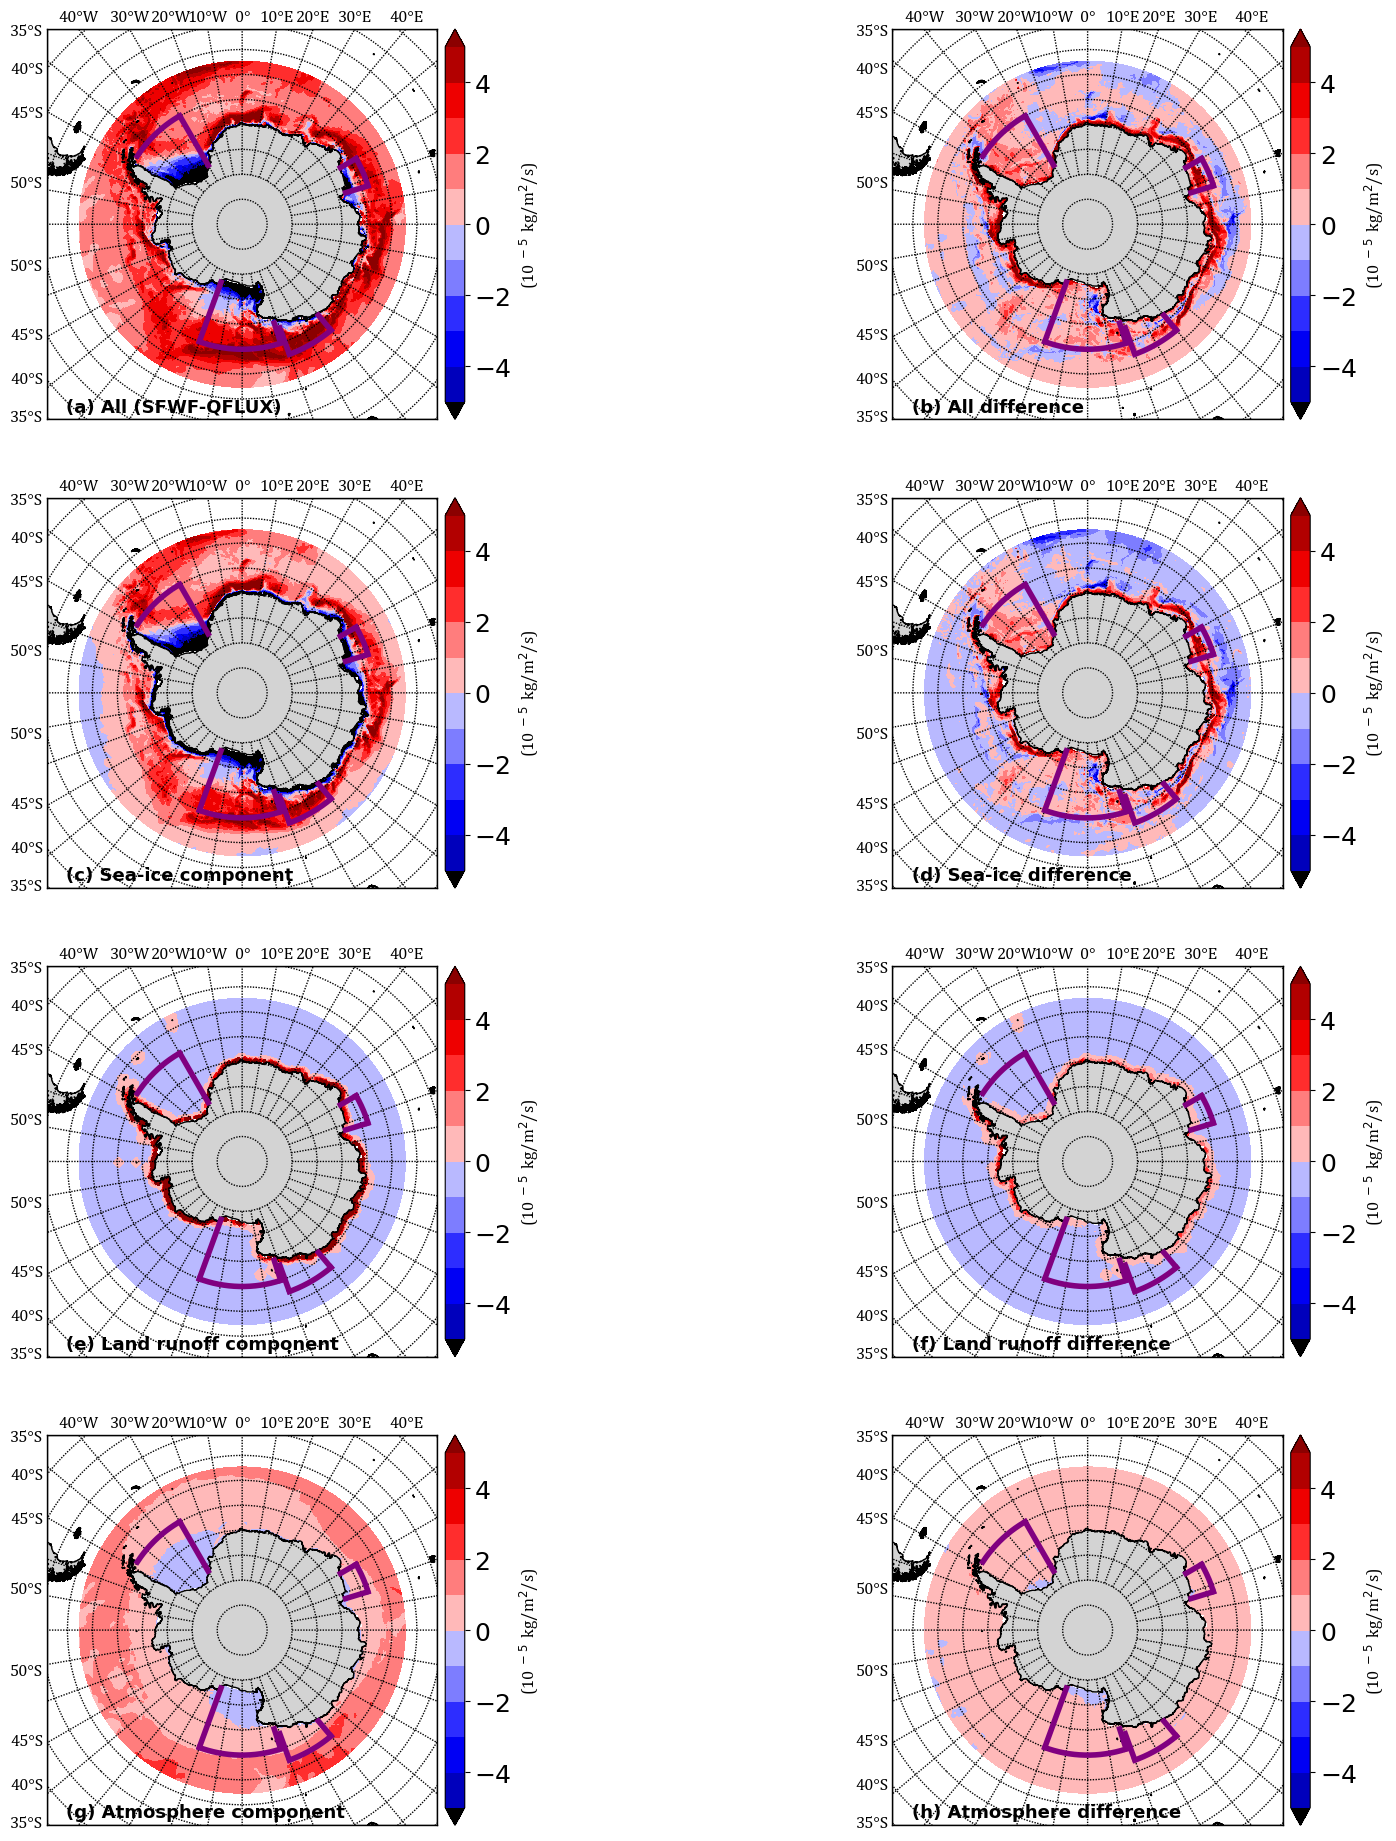

In [15]:
fig = plt.figure(figsize=(20,30), dpi=100)
#ax0 = fig.add_axes([0.1, 0.1, 0.8, 0.36],
                    #xticklabels=[])

ax = plt.subplot(5, 2, 1)
my_font = {'fontname':'Cambria', 'size':'12'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],All[:480,:]*100000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('darkred')
CP.cmap.set_under('black')
#CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=20,fmt='%1.1f')

cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=18) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^5$  kg/m$^2$/s)', **my_font)
#plt.suptitle("Jan",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.05, 0.02, '(a) All (SFWF-QFLUX)', transform=ax.transAxes,size=13, weight='bold')



ax = plt.subplot(5, 2, 2)
my_font = {'fontname':'Cambria', 'size':'12'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],All21[:480,:]*100000-All[:480,:]*100000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('darkred')
CP.cmap.set_under('black')
#CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=20,fmt='%1.1f')

cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=18) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^5$  kg/m$^2$/s)', **my_font)
#plt.suptitle("Jan",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.05, 0.02, '(b) All difference', transform=ax.transAxes,size=13, weight='bold')




ax = plt.subplot(5, 2, 3)
my_font = {'fontname':'Cambria', 'size':'12'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],ICE[:480,:]*100000-QFLUX1920T[:480,:]*100000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('darkred')
CP.cmap.set_under('black')
#CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
##    
cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=18) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^5$  kg/m$^2$/s)', **my_font)
#plt.suptitle("Jan",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.05, 0.02, '(c) Sea-ice component ', transform=ax.transAxes,size=13, weight='bold')



ax = plt.subplot(5, 2, 4)
my_font = {'fontname':'Cambria', 'size':'12'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],ICE21[:480,:]*100000-ICE[:480,:]*100000+QFLUX1920T[:480,:]*100000-QFLUX2100T[:480,:]*100000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('darkred')
CP.cmap.set_under('black')
#CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
##    
cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=18) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^5$  kg/m$^2$/s)', **my_font)
#plt.suptitle("Jan",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.05, 0.02, '(d) Sea-ice difference', transform=ax.transAxes,size=13, weight='bold')
  
    


ax = plt.subplot(5, 2, 5)
my_font = {'fontname':'Cambria', 'size':'12'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],LAND[:480,:]*100000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('darkred')
CP.cmap.set_under('black')
#CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
##    
cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=18) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^5$  kg/m$^2$/s)', **my_font)
#plt.suptitle("Jan",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.05, 0.02, '(e) Land runoff component ', transform=ax.transAxes,size=13, weight='bold')
  


ax = plt.subplot(5, 2, 6)
my_font = {'fontname':'Cambria', 'size':'12'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],LAND21[:480,:]*100000-LAND[:480,:]*100000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('darkred')
CP.cmap.set_under('black')
#CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
##    
cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=18) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^5$  kg/m$^2$/s)', **my_font)
#plt.suptitle("Jan",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.05, 0.02, '(f) Land runoff difference', transform=ax.transAxes,size=13, weight='bold')


ax = plt.subplot(5, 2, 7)
my_font = {'fontname':'Cambria', 'size':'12'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],ATM[:480,:]*100000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('darkred')
CP.cmap.set_under('black')
#CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=20,fmt='%1.1f')

cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=18) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^5$  kg/m$^2$/s)', **my_font)
#plt.suptitle("Jan",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.05, 0.02, '(g) Atmosphere component', transform=ax.transAxes,size=13, weight='bold')

ax = plt.subplot(5, 2, 8)
my_font = {'fontname':'Cambria', 'size':'12'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],ATM21[:480,:]*100000-ATM[:480,:]*100000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('darkred')
CP.cmap.set_under('black')
#CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=20,fmt='%1.1f')

cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=18) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^5$  kg/m$^2$/s)', **my_font)
#plt.suptitle("Jan",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.05, 0.02, '(h) Atmosphere difference ', transform=ax.transAxes,size=13, weight='bold')








    



plt.savefig("SALTbudgetplat555.png",bbox_inches='tight')

Text(0.05, 0.02, '(j) ocean component difference ')

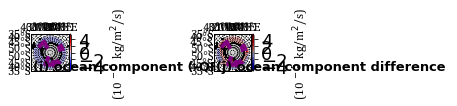

In [16]:
ax = plt.subplot(5, 2, 9)
my_font = {'fontname':'Cambria', 'size':'12'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],-QFLUX1920T[:480,:]*100000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('darkred')
CP.cmap.set_under('black')
#CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
##    
cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=18) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^5$  kg/m$^2$/s)', **my_font)
#plt.suptitle("Jan",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.05, 0.02, '(i) ocean component (-QFLUX) ', transform=ax.transAxes,size=13, weight='bold')
  
        
ax = plt.subplot(5, 2, 10)
my_font = {'fontname':'Cambria', 'size':'12'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8700000,height = 8700000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(TLONG,TLAT)
CP = map.contourf(x[:480,:],y[:480,:],QFLUX1920T[:480,:]*100000-QFLUX2100T[:480,:]*100000,levels = nice_levels,cmap = new_cmap,norm =norm,extend='both')
CP.cmap.set_over('darkred')
CP.cmap.set_under('black')
#CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

#CS2 = map.contour(x[:480,:],y[:480,:],sig[:480,:],[32.3],colors= 'darkblue',linestyles = 'solid',linewidths=1)
#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
#CS=map.contour(x,y,plotvar2,[0.1,0.3],colors = 'green', linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#x3,y3=map(lont3,latt3)
#map.plot(x3,y3,'red',linewidth=4)
#x7,y7=map(lont7,latt7)
#map.plot(x7,y7,'red',linewidth=4)
#x8,y8=map(lont8,latt8)
#map.plot(x8,y8,'red',linewidth=4)
##x9,y9=map(lont9,latt9)
#map.plot(x9,y9,'red',linewidth=4)

x4,y4=map(lont4,latt4)
map.plot(x4,y4,'purple',linewidth=4)
x10,y10=map(lont10,latt10)
map.plot(x10,y10,'purple',linewidth=4)
x11,y11=map(lont11,latt11)
map.plot(x11,y11,'purple',linewidth=4)
x12,y12=map(lont12,latt12)
map.plot(x12,y12,'purple',linewidth=4)
x13,y13=map(lont13,latt13)
map.plot(x13,y13,'purple',linewidth=4)
x14,y14=map(lont14,latt14)
map.plot(x14,y14,'purple',linewidth=4)

x6,y6=map(lont6,latt6)
map.plot(x6,y6,'purple',linewidth=4)

x15,y15=map(lont15,latt15)
map.plot(x15,y15,'purple',linewidth=4)
x16,y16=map(lont16,latt16)
map.plot(x16,y16,'purple',linewidth=4)
x17,y17=map(lont17,latt17)
map.plot(x17,y17,'purple',linewidth=4)

#plt.clabel(CS2,fontsize=20,fmt='%1.1f')
##    
cbar =map.colorbar(CP)
cbar.ax.tick_params(labelsize=18) 
#cbar.set_label('(m/s)', **my_font)
cbar.set_label('(10 $^-$$^5$  kg/m$^2$/s)', **my_font)
#plt.suptitle("Jan",**my_font)
#plt.xlabel("Time 295-09 (sea ice thickness)",**my_font)
ax.text(0.05, 0.02, '(j) ocean component difference ', transform=ax.transAxes,size=13, weight='bold')
     
    
    
